## **Important Libraries**

In [42]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re
from nltk.tokenize import word_tokenize , sent_tokenize
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
from nltk.stem import PorterStemmer , WordNetLemmatizer
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report , confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\INTEL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\INTEL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\INTEL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## **Load Dataset**

In [3]:
df = pd.read_csv("twitter_training - twitter_training.csv")

In [4]:
df.columns = ["Tweet_ID","Entity","Sentiment","Tweet"]

# Contains this 4 columns
df = df[["Tweet_ID", "Entity", "Sentiment", "Tweet"]]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


# See the First 5 rows

In [5]:
df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


# See the Last 5 rows

In [6]:
df.tail()

,Tweet_ID,Entity,Sentiment,Tweet
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...
74680,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [7]:
# Dataset shape
df.shape

(74681, 4)

In [8]:
# All Columns
df.columns

Index(['Tweet_ID', 'Entity', 'Sentiment', 'Tweet'], dtype='object')

In [9]:
# Checking Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74681 non-null  int64 
 1   Entity     74681 non-null  object
 2   Sentiment  74681 non-null  object
 3   Tweet      73823 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


## **EDA**

In [10]:
df.isna().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        858
dtype: int64

There are 858 missing values present on the Tweet column


In [11]:
# Handling the Missing Value on this dataset
df["Tweet"] = df["Tweet"].fillna("Unknown")

In [12]:
# Check the Duplicate value
df.duplicated().sum()

np.int64(3223)

In [13]:
df = df.drop_duplicates()

# Sentiment Distribution

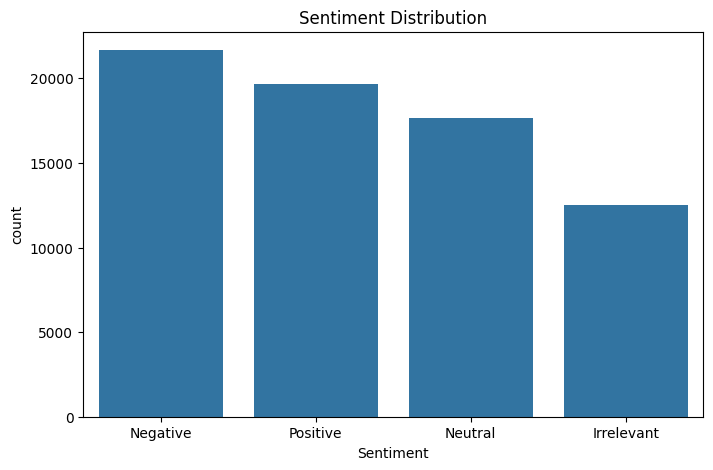

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(data = df, x = "Sentiment", order=df['Sentiment'].value_counts().index)

plt.title("Sentiment Distribution")
plt.show()

# Entity Distribution

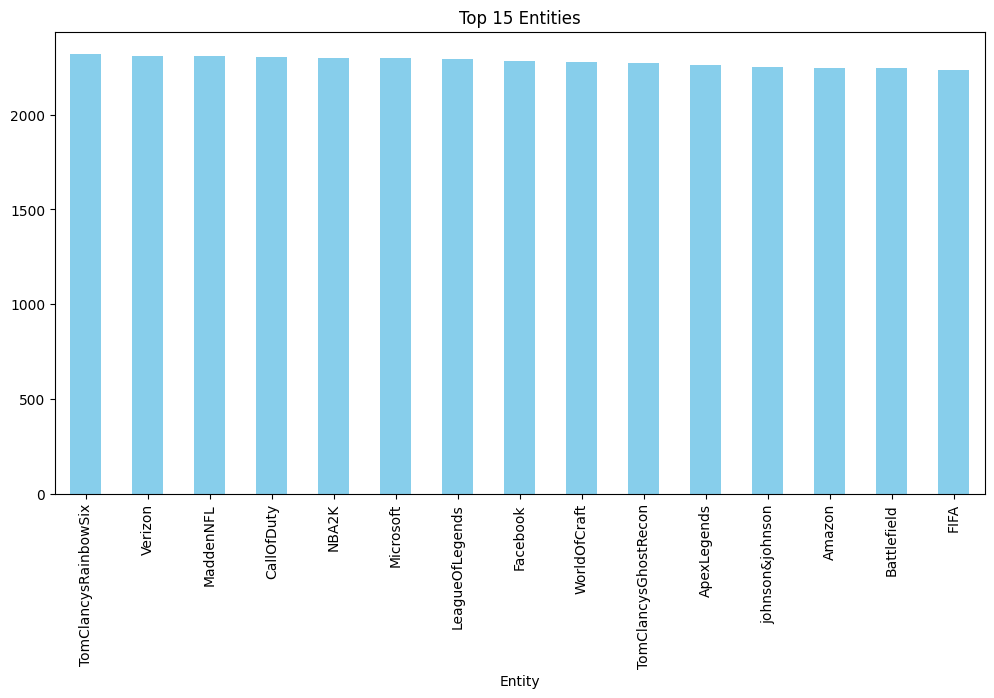

In [15]:
plt.figure(figsize=(12,6))

df['Entity'].value_counts().head(15).plot(kind="bar", color ='skyblue')

plt.title("Top 15 Entities")
plt.show()

# Text Length

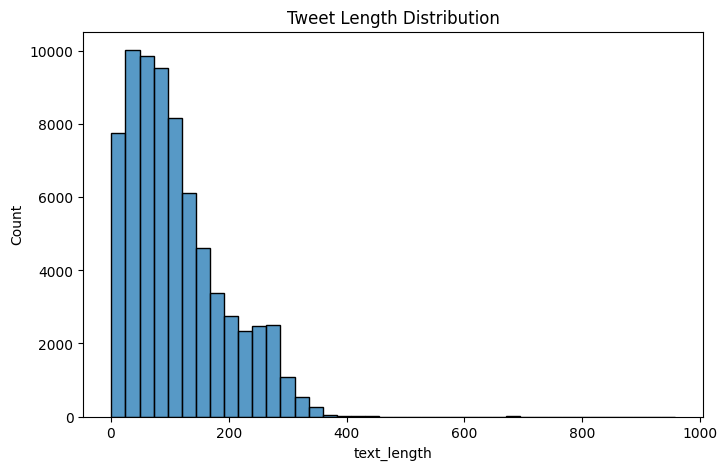

In [16]:
df["text_length"] = df["Tweet"].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["text_length"], bins=40)

plt.title("Tweet Length Distribution")
plt.show()


# WordCloude

Postive Text

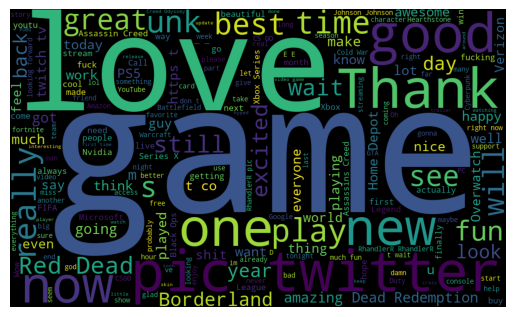

In [21]:
positive_text = " ".join(df[df["Sentiment"]=="Positive"]["Tweet"].astype(str))

wordcloud = WordCloud(width=1000,height=600, background_color="black").generate(positive_text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

Negative Text

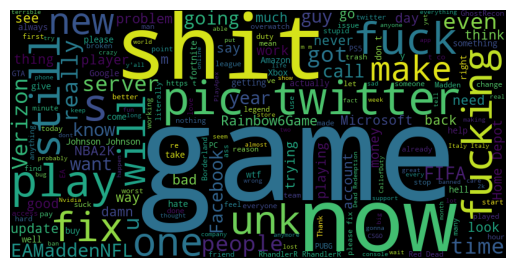

In [26]:
negative_text = " ".join(df[df["Sentiment"]=="Negative"]["Tweet"].astype(str))

wordcloud = WordCloud(width=800, height=400,background_color="black").generate(negative_text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

# NLP Preprocessing


In [28]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [31]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)



In [34]:
df["clean_text"] = df["Tweet"].apply(clean_text)

df.head()

,Tweet_ID,Entity,Sentiment,Tweet,text_length,clean_text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,51,coming border kill
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,50,im getting borderland kill
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,51,im coming borderland murder
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,57,im getting borderland murder
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,53,im getting borderland murder


# Feature Extraction

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

x = tfidf.fit_transform(df["clean_text"])

y = df["Sentiment"]

# Performing Model And Evaluation

# Train Test Apply

In [44]:
xtrain , xtest ,ytrain, ytest = train_test_split(x,y , test_size=.2, random_state=42)

## **Performing Random Forest**

In [45]:
rf = RandomForestClassifier()

In [46]:
model_rf = rf.fit(xtrain,ytrain)
print("Training Score : ", model_rf.score(xtrain,ytrain))

Training Score :  0.9620578665640416
